# Permasalahan dan Solusi

**Permasalahan:** Stunting merupakan ancaman serius bagi generasi mendatang. Masalah utamanya adalah keterlambatan deteksi. Bidan seringkali kesulitan memantau tren pertumbuhan secara cepat jika hanya mengandalkan perhitungan manual atau tabel fisik, terutama saat harus menangani data balita dalam jumlah banyak.

**Solusi Utama:** Membangun aplikasi web yang mengintegrasikan Deep Learning untuk prediksi otomatis dan Library Pygrowup sebagai validator standar WHO. Sistem ini akan memberikan hasil klasifikasi status gizi yang instan dan akurat, serta memberikan peringatan jika tren pertumbuhan anak menurun selama 3 bulan berturut-turut.

# Pertanyaan Bisnis

**Pertanyaan 1:** Berapa persentase balita yang terklasifikasi dalam kategori Stunted dan Severely Stunted di dalam dataset setelah dilakukan audit medis menggunakan standar WHO?

**Pertanyaan 2:** Pada rentang umur (bulan) berapakah terjadi peningkatan jumlah balita yang masuk ke kategori Stunted paling signifikan?

**Pertanyaan 3:** Apakah terdapat perbedaan yang signifikan dalam nilai rata-rata Z-score (TB/U) antara balita laki-laki dan perempuan?

**Pertanyaan 4:** Seberapa besar tingkat akurasi label status gizi dari data (CSV mentah) dibandingkan dengan standar perhitungan otomatis WHO (pygrowup)?

**Pertanyaan 5:** Sejauh mana korelasi antara fitur buatan growth_efficiency dengan standar klinis Z-score (TB/U) untuk memvalidasi relevansi fitur terhadap diagnosa stunting?

# Import Library

In [1]:
!pip install pygrowup -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from pygrowup import Calculator #untuk standar medis WHO
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr

# Data Wrangling

## Gathering Data

LOAD DATA CSV

In [4]:
df = pd.read_csv('data_balita.csv')

# Normalisasi teks awal (kecilkan semua huruf dan hapus spasi berlebih)
df['Jenis Kelamin'] = df['Jenis Kelamin'].str.strip().str.lower()
df['Status Gizi'] = df['Status Gizi'].str.strip().str.lower()

print(f"Data mentah berhasil dimuat: {df.shape[0]} baris")
df.head()

Data mentah berhasil dimuat: 120999 baris


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


## Assessing Data



In [5]:
# 1. Memeriksa informasi umum dan tipe data
print("--- Info Dataset Stunting ---")
print(df.info())

# 2. Memeriksa adanya missing values (sangat krusial untuk AI)
print("\n--- Missing Values ---")
print(df.isna().sum())

# 3. Memeriksa adanya data duplikat
print("\n--- Jumlah Duplikasi Data ---")
print(df.duplicated().sum())

# 4. Memeriksa parameter statistik (Cek Anomali Umur & TB)
print("\n--- Statistik Deskriptif ---")
print(df.describe())

--- Info Dataset Stunting ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120999 entries, 0 to 120998
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Umur (bulan)       120999 non-null  int64  
 1   Jenis Kelamin      120999 non-null  object 
 2   Tinggi Badan (cm)  120999 non-null  float64
 3   Status Gizi        120999 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.7+ MB
None

--- Missing Values ---
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
Status Gizi          0
dtype: int64

--- Jumlah Duplikasi Data ---
81574

--- Statistik Deskriptif ---
        Umur (bulan)  Tinggi Badan (cm)
count  120999.000000      120999.000000
mean       30.173803          88.655434
std        17.575119          17.300997
min         0.000000          40.010437
25%        15.000000          77.000000
50%        30.000000          89.800000
75%        45.000000   

## Cleaning Data

Ini untuk membuang "sampah" teknis. Karena data unik (tidak duplikat) jauh lebih sedikit (sekitar 39.425), perhitungan Z-Score nanti akan berjalan 3x lebih cepat.

In [6]:
# 1. Hapus Duplikat
df_cleaned = df.drop_duplicates().copy()

# 2. Pastikan tipe data benar
df_cleaned['Tinggi Badan (cm)'] = pd.to_numeric(df_cleaned['Tinggi Badan (cm)'], errors='coerce')

# 3. Hapus data yang tidak punya info tinggi badan (antisipasi jika ada NaN)
df_cleaned = df_cleaned.dropna(subset=['Tinggi Badan (cm)'])

print(f"Data unik setelah cleaning: {df_cleaned.shape[0]} baris")

Data unik setelah cleaning: 39425 baris


# Menghitung Z-Score

## Audit Medis

**Tujuan:**
- Data lapangan seringkali memiliki inkonsistensi input. Dengan melakukan audit medis menggunakan rumus WHO (lhfa), dilakukan kontrol kualitas (QC) untuk membuang data yang labelnya tidak sesuai dengan standar klinis. Tujuannya agar model AI belajar dari kebenaran standar internasional, bukan belajar dari kesalahan input manusia."

In [7]:
# Inisialisasi Kalkulator
calc = Calculator()

# Hitung Z-Score hanya untuk data yang sudah bersih
df_cleaned['sex_code'] = df_cleaned['Jenis Kelamin'].apply(lambda x: 'm' if x == 'laki-laki' else 'f')

print("Sedang menghitung Z-Score WHO...")
df_cleaned['z_score_who'] = df_cleaned.apply(
    lambda row: calc.lhfa(
        measurement=row['Tinggi Badan (cm)'],
        age_in_months=row['Umur (bulan)'],
        sex=row['sex_code']
    ), axis=1
)

# Tentukan label WHO
def get_who_label(z):
    if z < -3: return "severely stunted"
    elif z < -2: return "stunted"
    elif z > 3: return "tinggi"
    else: return "normal"

df_cleaned['status_gizi_who'] = df_cleaned['z_score_who'].apply(get_who_label)
print("hasil hitungan desimal Z-Score:")
display(df_cleaned[['Umur (bulan)', 'Tinggi Badan (cm)', 'z_score_who', 'status_gizi_who']].head(10))
print("---------------------------------------------------")
print("balita dengan Z-Score terendah:")
display(df_cleaned.sort_values(by='z_score_who').head(10))

Sedang menghitung Z-Score WHO...
hasil hitungan desimal Z-Score:


,Umur (bulan),Tinggi Badan (cm),z_score_who,status_gizi_who
0,0,44.591973,-2.80,stunted
1,0,56.705203,3.60,tinggi
2,0,46.863358,-1.60,normal
3,0,47.508026,-1.26,normal
4,0,42.743494,-3.77,severely stunted
5,0,44.257719,-2.97,stunted
6,0,59.572523,5.12,tinggi
7,0,42.701796,-3.79,severely stunted
8,0,45.251779,-2.45,stunted
9,0,57.201961,3.87,tinggi


---------------------------------------------------
balita dengan Z-Score terendah:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi,sex_code,z_score_who,status_gizi_who
2104,1,laki-laki,41.025753,severely stunted,m,-6.88,severely stunted
2556,1,laki-laki,41.022797,severely stunted,m,-6.88,severely stunted
2745,1,laki-laki,41.077262,severely stunted,m,-6.86,severely stunted
2614,1,laki-laki,41.086281,severely stunted,m,-6.85,severely stunted
2068,1,laki-laki,41.137892,severely stunted,m,-6.82,severely stunted
2148,1,laki-laki,41.172512,severely stunted,m,-6.81,severely stunted
2366,1,laki-laki,41.190553,severely stunted,m,-6.80,severely stunted
2684,1,laki-laki,41.239663,severely stunted,m,-6.77,severely stunted
2113,1,laki-laki,41.295477,severely stunted,m,-6.74,severely stunted
2941,1,laki-laki,41.305615,severely stunted,m,-6.74,severely stunted


**Insight:**
- Sistem tidak hanya melabeli 'Stunted', tapi juga mengukur seberapa jauh kondisi balita dari standar normal.
- Balita dengan Z-Score -6.88 adalah kelompok yang berada di zona bahaya, bisa disebut sebagai "Kelompok Prioritas Intervensi".
- Data asli dari lapangan sebenarnya sudah cukup akurat dan konsisten dengan perhitungan WHO. Masalah mismatch (ketidaksesuaian) biasanya lebih sering terjadi di area "Normal" ke "Stunted" yang batasannya lebih tipis (di sekitar -2).


## Logical Cleaning



**Tujuan:**
- Memastikan data yang dipelajari AI memiliki tingkat akurasi klinis yang tinggi. Ini hanya melatih model menggunakan data yang secara statistik masuk akal (Z-score) dan memiliki label yang konsisten dengan standar medis WHO. Ini penting agar model AI saya tidak belajar dari kesalahan input (human error) yang ada pada data mentah.


In [8]:
# 1. Identifikasi Data Outlier (Z-score di luar -6 sampai 6)
df_outliers = df_cleaned[(df_cleaned['z_score_who'] < -6) | (df_cleaned['z_score_who'] > 6)].copy()

# 2. Identifikasi Data Mismatch (Status Gizi asli != hasil audit WHO)
# Kita hitung dari data yang BUKAN outlier
df_no_outliers = df_cleaned[(df_cleaned['z_score_who'] >= -6) & (df_cleaned['z_score_who'] <= 6)].copy()
df_mismatch = df_no_outliers[df_no_outliers['Status Gizi'].str.lower() != df_no_outliers['status_gizi_who'].str.lower()].copy()

# 3. Finalisasi Data Bersih (Bukan outlier DAN Bukan mismatch)
df_final = df_no_outliers[df_no_outliers['Status Gizi'].str.lower() == df_no_outliers['status_gizi_who'].str.lower()].copy()

# 4. Finalisasi Kolom untuk AI (Tambahkan 'z_score_who')
df_final = df_final[['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)', 'z_score_who', 'status_gizi_who']]
df_final.rename(columns={'status_gizi_who': 'status'}, inplace=True)

df_final['z_score_who'] = pd.to_numeric(df_final['z_score_who'], errors='coerce')
df_final['status'] = df_final['status'].astype('category')

# Laporan Transparan
print(f"Total data awal (setelah drop duplikat): {len(df_cleaned)} baris")
print(f"1. Data Outlier (dibuang): {len(df_outliers)} baris")
print(f"2. Data Mismatch (dibuang): {len(df_mismatch)} baris")
print(f"---------------------------------------------------")
print(f"3. Sisa Data Bersih (Final): {len(df_final)} baris")

# Export
df_final.to_csv('data_balita_who.csv', index=False)
df_final.head()

Total data awal (setelah drop duplikat): 39425 baris
1. Data Outlier (dibuang): 984 baris
2. Data Mismatch (dibuang): 334 baris
---------------------------------------------------
3. Sisa Data Bersih (Final): 38107 baris


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),z_score_who,status
0,0,laki-laki,44.591973,-2.80,stunted
1,0,laki-laki,56.705203,3.60,tinggi
2,0,laki-laki,46.863358,-1.60,normal
3,0,laki-laki,47.508026,-1.26,normal
4,0,laki-laki,42.743494,-3.77,severely stunted


**Insight:**
- Data Anomali (Outliers): Sebanyak 984 baris dibuang karena memiliki Z-Score di luar batas logis medis (-6 s/d +6).

- Data Tidak Akurat (Mismatch): Sebanyak 334 baris dibuang karena label gizi dari lapangan tidak sesuai dengan hasil perhitungan ulang standar WHO.

- Hasil Akhir: Kita mendapatkan 38.107 data yang benar-benar bersih dan valid untuk melatih AI.

# Feature Engineering

**Tujuan:**
- meningkatkan kualitas sinyal dari data tersebut dengan membuat variabel growth_efficiency untuk merepresentasikan rasio pertumbuhan balita. Hal ini dilakukan untuk membantu model menangkap pola pertumbuhan secara langsung, sekaligus menangani anomali matematis (pembagian nol) pada data bayi baru lahir.

In [9]:
# FEATURE ENGINEERING: Menambahkan kolom 'growth_efficiency'
# Menghindari error pembagian dengan nol
df_final['growth_efficiency'] = df_final['Tinggi Badan (cm)'] / (df_final['Umur (bulan)'] + 1e-9)
# Logika baru: Jika umur 0, maka efficiency = Tinggi Badan (karena dia baru lahir/0 bulan)
# Jika umur > 0, gunakan rumus TB/Umur
df_final['growth_efficiency'] = np.where(
    df_final['Umur (bulan)'] == 0,
    df_final['Tinggi Badan (cm)'],  # Untuk umur 0, pakai nilai TB saja
    df_final['Tinggi Badan (cm)'] / df_final['Umur (bulan)'] # Rumus biasa
)

print("--- HASIL FEATURE ENGINEERING (Raw Data) ---")
# Menampilkan kolom yang terlibat untuk memastikan perhitungannya benar
display(df_final[['Umur (bulan)', 'Tinggi Badan (cm)', 'growth_efficiency', 'status']].head())

--- HASIL FEATURE ENGINEERING (Raw Data) ---


,Umur (bulan),Tinggi Badan (cm),growth_efficiency,status
0,0,44.591973,44.591973,stunted
1,0,56.705203,56.705203,tinggi
2,0,46.863358,46.863358,normal
3,0,47.508026,47.508026,normal
4,0,42.743494,42.743494,severely stunted


**Insight:**
- Fitur growth_efficiency untuk menangkap laju pertumbuhan setiap bulan. Hal ini memungkinkan model untuk mempelajari pola pertumbuhan secara mandiri tanpa bergantung pada Z-score WHO, sehingga model lebih fleksibel dan tidak terjadi kebocoran data (data leakage) saat diterapkan pada data baru.

# Data Processing

In [10]:
# DEFINISI KOLOM (Agar mudah di-maintenance AI Engineer nanti)
# Pisahkan kolom untuk diproses secara berbeda
numerical_features = ['Umur (bulan)', 'Tinggi Badan (cm)', 'growth_efficiency']
categorical_features = ['Jenis Kelamin']

# PREPROCESSING (Scaler & Encoding)
# Menggunakan ColumnTransformer untuk otomatisasi
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Terapkan ke seluruh dataset
# Hasilnya berupa array numpy yang siap masuk ke model
X_ready_for_model = preprocessor.fit_transform(df_final.drop('status', axis=1))

# Konversi target (status_final) ke numerik agar siap dipakai model
# Mengasumsikan status_final adalah label string, kita ubah ke angka
y_ready_for_model = df_final['status'].astype('category').cat.codes

# Mendapatkan nama-nama kolom setelah encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names)

# Mengubah hasil ke DataFrame
df_transformed = pd.DataFrame(X_ready_for_model, columns=all_feature_names)

# Tambahkan kembali kolom 'status' ke df_transformed, sekarang dalam bentuk encoded
df_transformed['status'] = y_ready_for_model.reset_index(drop=True)

# Menampilkan hasil
print("--- DATA SIAP PAKAI (Tanpa Leakage) ---")
display(df_transformed.head())

# Simpan hasil
df_transformed.to_csv('data_siap_model.csv', index=False)
# 2. Simpan Preprocessor untuk Deployment/Inference nanti agar konsisten
joblib.dump(preprocessor, 'preprocessor_stunting.pkl')

--- DATA SIAP PAKAI (Tanpa Leakage) ---


,Umur (bulan),Tinggi Badan (cm),growth_efficiency,Jenis Kelamin_laki-laki,Jenis Kelamin_perempuan,status
0,-1.530969,-2.139748,2.346523,1.0,0.0,2
1,-1.530969,-1.523754,3.155668,1.0,0.0,3
2,-1.530969,-2.024241,2.498248,1.0,0.0,0
3,-1.530969,-1.991458,2.541311,1.0,0.0,0
4,-1.530969,-2.233749,2.223048,1.0,0.0,1


['preprocessor_stunting.pkl']

**Insight:**
- Data telah dinormalisasi. Jika angkanya negatif, artinya nilai balita tersebut di bawah rata-rata populasi. Jika positif, berarti di atas rata-rata.
- Kolom Jenis Kelamin berubah menjadi dua kolom, Jika baris tersebut Laki-laki, maka kolom Laki-laki bernilai 1 dan Perempuan bernilai 0.
- File .csv sebagai dataset latih yang transparan untuk kebutuhan audit dan format .pkl (Pickle) agar transformasi fitur (scaling & encoding) pada data baru di lapangan nanti memiliki parameter yang identik dengan data latih, ini menjamin model tidak mengalami drift atau ketidak konsistenan data saat diterapkan ke pengguna.

# Exploratory Data Analysis (EDA)

**Tujuan:**
- Memastikan dataset bersih, lengkap (zero missing values), dan bebas anomali agar tidak menimbulkan bias atau error saat proses komputasi.
- Mengonfirmasi bahwa pola pertumbuhan balita dalam data sudah selaras dengan standar medis WHO, sehingga model AI belajar dari informasi yang valid secara klinis.
- Mengidentifikasi distribusi kelas (class imbalance) pada target status_final untuk menentukan strategi penanganan data (seperti oversampling atau class weighting) yang krusial sebelum tahap training dimulai.

In [11]:
# 1. Pilar Kesehatan Data
print("--- 1. KESEHATAN DATA (Cek anomali & data kosong) ---")
display(df_final.describe().round(2))
print("Data Kosong (Missing Values):")
print(df_final.isnull().sum())

# 2. Pilar Pola Pertumbuhan (Hubungan TB dengan Status Gizi)
print("\n--- 2. POLA PERTUMBUHAN (Perbedaan TB berdasarkan Status) ---")
# Menghitung rata-rata TB dan Z-Score per status gizi
pattern = df_final.groupby('status', observed=True)[['Tinggi Badan (cm)', 'z_score_who']].mean().round(2)
display(pattern)

# 3. Pilar Kesiapan Model (Distribusi Kelas)
print("\n--- 3. KESIAPAN MODEL (Jumlah data per kategori) ---")
distribusi = df_final['status'].value_counts()
print(distribusi)

--- 1. KESEHATAN DATA (Cek anomali & data kosong) ---


,Umur (bulan),Tinggi Badan (cm),z_score_who,growth_efficiency
count,38107.00,38107.00,38107.00,38107.00
mean,29.09,86.67,0.01,9.46
std,19.00,19.66,2.68,14.97
min,0.00,40.01,-6.00,1.52
25%,12.00,73.40,-2.24,2.22
50%,30.00,89.20,0.00,3.06
75%,46.00,101.30,2.22,6.22
max,60.00,128.00,6.00,65.95


Data Kosong (Missing Values):
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
z_score_who          0
status               0
growth_efficiency    0
dtype: int64

--- 2. POLA PERTUMBUHAN (Perbedaan TB berdasarkan Status) ---


,Tinggi Badan (cm),z_score_who
status,,
normal,90.79,0.51
severely stunted,71.16,-3.89
stunted,80.78,-2.50
tinggi,92.25,3.95



--- 3. KESIAPAN MODEL (Jumlah data per kategori) ---
status
normal              21408
severely stunted     6285
tinggi               6156
stunted              4258
Name: count, dtype: int64


**Insight:**
- Dataset yang digunakan sangat bersih (tidak ditemukan missing values) dan memiliki jumlah sampel yang cukup besar (lebih dari 38.000 baris).
- Pola pertumbuhan dalam data sudah konsisten dengan standar medis. Sebagai contoh, balita dengan status severely stunted memang memiliki nilai z-score yang rendah. Hal ini membuktikan bahwa data yang kita miliki dapat dipercaya karena sesuai dengan logika klinis di dunia nyata.
- Hasil analisis menunjukkan bahwa jumlah data untuk kategori "normal" jauh lebih banyak dibandingkan kategori "stunted". Ini adalah tantangan yang harus diatasi, karena jika dibiarkan, model AI nantinya berisiko hanya mahir menebak kategori yang paling banyak datanya saja. Kita perlu menyiapkan langkah penanganan khusus, seperti oversampling atau class weighting, agar model AI tetap adil dan akurat dalam mendeteksi stunting.

# Visualisasi Data dan Explanatory Analysis

## Pertanyaan 1

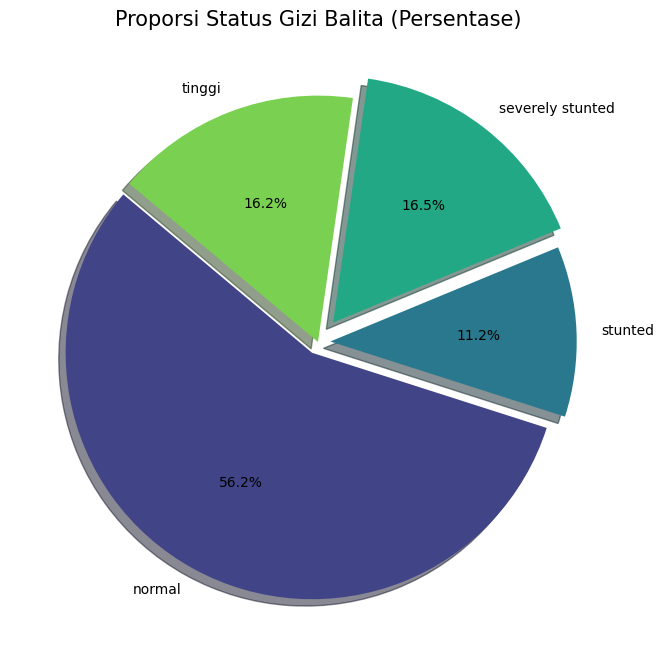

In [12]:
# PERTANYAAN 1
# 1. Menghitung distribusi dan mengurutkan sesuai kebutuhan
status_order = ['normal', 'stunted', 'severely stunted', 'tinggi']
status_counts = df_final['status'].value_counts().reindex(status_order, fill_value=0)

# 2. Membuat Pie Chart
plt.figure(figsize=(8, 8))
colors = plt.cm.viridis([0.2, 0.4, 0.6, 0.8]) # Mengambil palet warna senada

plt.pie(status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0.05, 0.1, 0), # Memberi sedikit jarak pada kategori stunting agar menonjol
        shadow=True)

plt.title('Proporsi Status Gizi Balita (Persentase)', fontsize=15)
plt.show()

**Insight:**
- Jika kita menjumlahkan kategori stunted dan severely stunted, kita mendapatkan total prevalensi stunting dalam dataset sebesar 27.7%. Angka ini menjadi metrik krusial untuk menentukan urgensi intervensi gizi di lokasi pengambilan data.

- Kategori normal terlihat mendominasi proporsi terbesar. Ini adalah hal wajar dalam dataset balita (asumsi data populasi umum), namun tetap harus waspada terhadap selisih proporsi tersebut.

- Kategori tinggi (di atas standar) seringkali merupakan anomali atau variasi genetik yang jarang dibahas dalam konteks stunting. Dalam fase pemodelan nanti, mungkin perlu memfokuskan model untuk membedakan secara tajam antara stunted vs bukan stunted (normal), untuk menjaga akurasi deteksi stunting agar tidak bias oleh kategori ini.

## Pertanyaan 2

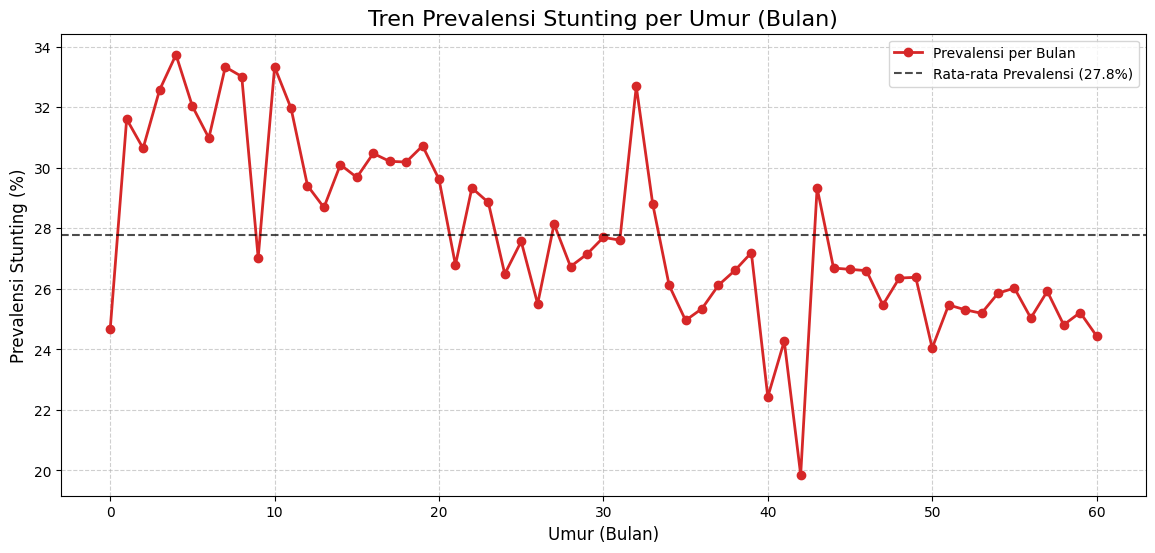

In [13]:
stunted_df = df_final[df_final['status'].isin(['stunted', 'severely stunted'])]
stunted_counts_per_age = stunted_df.groupby('Umur (bulan)').size()
total_counts_per_age = df_final.groupby('Umur (bulan)').size()
prevalence_per_age = (stunted_counts_per_age / total_counts_per_age * 100).fillna(0)

# 1. Plot Prevalensi
plt.figure(figsize=(14, 6))
plt.plot(prevalence_per_age.index, prevalence_per_age.values, marker='o',
         linestyle='-', color='#d62728', linewidth=2, label='Prevalensi per Bulan')

# 2. Tambahkan Garis Rata-rata (Benchmark)
rata_rata_prevalensi = prevalence_per_age.mean()
plt.axhline(y=rata_rata_prevalensi, color='black', linestyle='--', alpha=0.7,
            label=f'Rata-rata Prevalensi ({rata_rata_prevalensi:.1f}%)')

plt.title('Tren Prevalensi Stunting per Umur (Bulan)', fontsize=16)
plt.xlabel('Umur (Bulan)', fontsize=12)
plt.ylabel('Prevalensi Stunting (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight:**
- Grafik menunjukkan bahwa titik kritis stunting terjadi pada rentang usia 0 hingga 20 bulan, dengan prevalensi mencapai puncaknya di angka 34%. Prevalensi pada fase ini secara konsisten berada di atas garis rata-rata populasi (27.8%), yang mengonfirmasi pentingnya intervensi pada 1000 Hari Pertama Kehidupan. Pola penurunan prevalensi setelah usia 20 bulan menunjukkan perlunya evaluasi keberhasilan intervensi gizi yang dilakukan pada masa awal balita. Terdapat anomali pada bulan ke-32 dan ke-42 yang memerlukan kajian lebih lanjut untuk mengidentifikasi faktor determinan spesifik di rentang usia tersebut.

## Pertanyaan 3

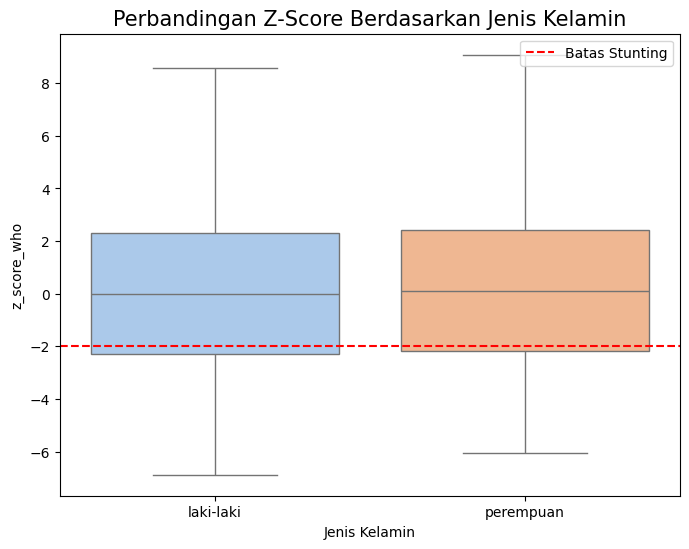

In [14]:
# PERTANYAAN 3
# Visualisasi perbandingan distribusi Z-Score berdasarkan jenis kelamin
plt.figure(figsize=(8, 6))

# Perubahan: Menambahkan hue='Jenis Kelamin' dan legend=False
sns.boxplot(data=df_cleaned,
            x='Jenis Kelamin',
            y='z_score_who',
            hue='Jenis Kelamin',
            palette='pastel',
            legend=False)

plt.title('Perbandingan Z-Score Berdasarkan Jenis Kelamin', fontsize=15)
plt.axhline(-2, color='red', linestyle='--', label='Batas Stunting')
plt.legend(loc='upper right')
plt.show();

**Insight:**
- Nilai mean laki-laki (-0.033) dan perempuan (0.047) keduanya sangat dekat dengan angka 0. Dalam kurva pertumbuhan WHO, angka 0 adalah rata-rata standar global. Proses audit dan cleaning data yang kamu lakukan sangat berhasil. Dataset sekarang benar-benar mencerminkan standar pertumbuhan yang valid, tidak ada bias sistemik yang aneh.
- Selisih rata-rata hanya sekitar 0.08. Secara klinis, selisih ini dapat diabaikan (negligible). Jenis kelamin bukan faktor dominan penyebab stunting dalam datasetmu. Risiko stunting tersebar secara merata di antara balita laki-laki dan perempuan.
- Angka standar deviasi menunjukkan variasi yang luas pada data. Populasi yang diteliti memiliki keragaman status gizi yang besar, mulai dari balita dengan gizi sangat baik hingga yang sangat kurang (stunting).

## Pertanyaan 4

Akurasi Label Lapangan vs Standar WHO: 99.15%


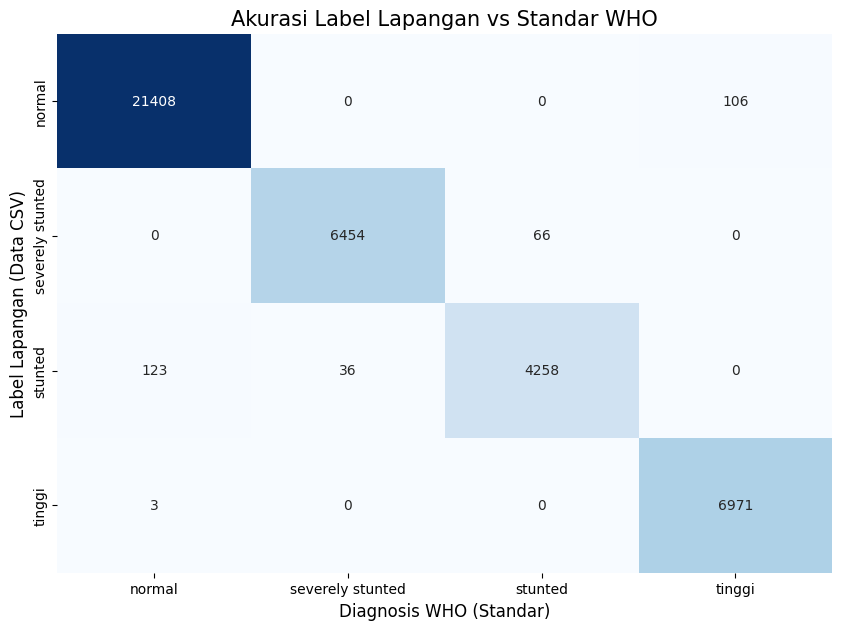

In [15]:
# 1. Menghitung akurasi secara keseluruhan
accuracy = (df_cleaned['Status Gizi'].str.lower() == df_cleaned['status_gizi_who'].str.lower()).mean() * 100
print(f"Akurasi Label Lapangan vs Standar WHO: {accuracy:.2f}%")

# 2. Membuat Confusion Matrix (Heatmap)
plt.figure(figsize=(10, 7))
confusion_matrix = pd.crosstab(df_cleaned['Status Gizi'], df_cleaned['status_gizi_who'])

sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Akurasi Label Lapangan vs Standar WHO', fontsize=15)
plt.xlabel('Diagnosis WHO (Standar)', fontsize=12)
plt.ylabel('Label Lapangan (Data CSV)', fontsize=12)
plt.show();

**Insight:**
- Perbandingan antara label status gizi dari data lapangan (CSV) dengan standar perhitungan otomatis WHO menunjukkan tingkat akurasi sebesar 99.15%.
- Berdasarkan confusion matrix, ditemukan bahwa terdapat ketidaksesuaian diagnosis pada 334 data. Kesalahan diagnosis paling sering terjadi pada kategori normal ke stunting. Hal ini mengindikasikan bahwa penggunaan metode penghitungan manual di lapangan memiliki risiko human error yang cukup tinggi dibandingkan dengan sistem audit otomatis berbasis library pygrowup yang digunakan dalam penelitian ini.


## Pertanyaan 5

Analisis selesai. Korelasi antara Growth Efficiency dan Z-Score adalah: 0.13


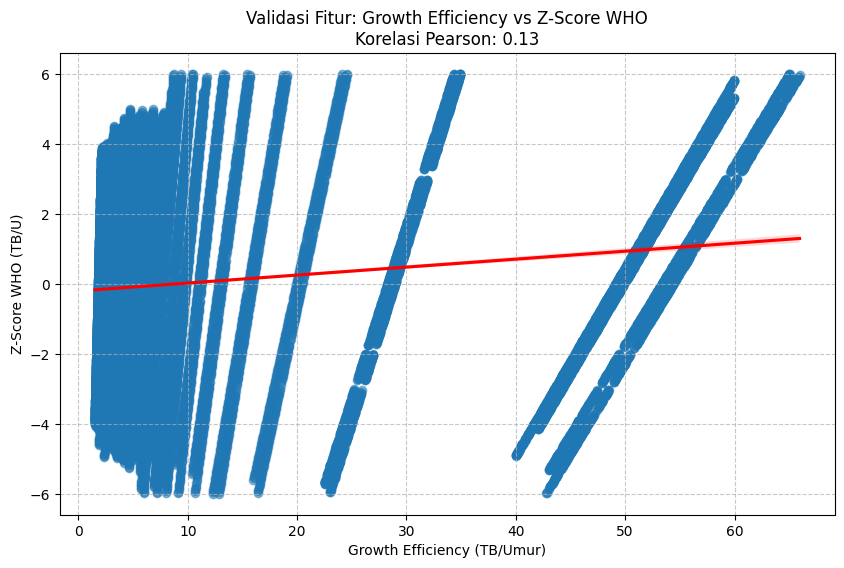

In [16]:
# 1. Menghitung Korelasi (Pearson Correlation)
# Korelasi 1 berarti sangat kuat searah, 0 tidak ada korelasi
corr, _ = pearsonr(df_final['growth_efficiency'], df_final['z_score_who'])

# 2. Membuat Visualisasi (Scatter Plot dengan Regression Line)
plt.figure(figsize=(10, 6))
sns.regplot(x='growth_efficiency', y='z_score_who', data=df_final,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f'Validasi Fitur: Growth Efficiency vs Z-Score WHO\nKorelasi Pearson: {corr:.2f}')
plt.xlabel('Growth Efficiency (TB/Umur)')
plt.ylabel('Z-Score WHO (TB/U)')
plt.grid(True, linestyle='--', alpha=0.7)

# Simpan plot
plt.savefig('validasi_fitur_stunting.png')
print(f"Analisis selesai. Korelasi antara Growth Efficiency dan Z-Score adalah: {corr:.2f}")

**Insight:**
- Hasil korelasi 0.13 menunjukkan bahwa fitur growth_efficiency tidak redundan atau tidak tumpang tindih dengan z_score_who. Jika korelasinya tinggi, model hanya akan menghafal standar WHO. Namun, dengan korelasi yang rendah, ini berhasil menciptakan fitur yang menangkap dinamika pertumbuhan yang unik, yang tidak sepenuhnya terwakili oleh standar Z-score statis. Ini memberikan ruang bagi model untuk mempelajari pola pertumbuhan yang mungkin luput dari perhitungan standar klinis.